# ============================================================
# NHS BENCHMARK COMPARISON
# CSEW Self-Reported Rates vs NHS Referral Rates
# Gap Analysis Table + Chart
# ============================================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Create output folder

In [3]:
output_folder = "nhs_benchmark_outputs"
os.makedirs(output_folder, exist_ok=True)

# Load CSEW dataset

In [4]:
csew_file = "csew_dataset.xlsx"

# Check sheet names first


In [5]:
xls = pd.ExcelFile(csew_file)
print("Available CSEW sheets:")
print(xls.sheet_names)

Available CSEW sheets:
['Correction', 'Cover sheet', 'Table of contents', 'Notes', 'Table S1', 'Table S2', 'Table S3', 'Table S4', 'Table S5', 'Table S6', 'Table S7', 'Table S8', 'Table S9', 'Table S10', 'Table S11', 'Table S12', 'Table S13', 'Table S14 ', 'Table S15', 'Table S16', 'Table S17', 'Worksheet S18', 'Table S19', 'Table S20', 'Table S21', 'Table S22', 'Table S23', 'Table S24', 'Table S25', 'Table S26', 'Table S27', 'Table S28', 'Table S29', 'Table S30', 'Table S31', 'Table S32', 'Table S33', 'Table S34', 'Table S35', 'Table S36', 'Table S37', 'Table S38a', 'Table S38b', 'Table S39', 'Table S40', 'Table S41', 'Table S42', 'Table S43a', 'Table S43b', 'Table S43c', 'Table S44']


# Load required CSEW sheet

In [6]:
csew_raw = pd.read_excel(
    csew_file,
    sheet_name="Table S44",
    header=None
)

print("\nCSEW Preview:")
print(csew_raw.head(15))


CSEW Preview:
                                                  0   \
0  Table S44: Prevalence of harassment experience...   
1          England and Wales, year ending March 2024   
2  This worksheet contains one table. Some cells ...   
3                            Link to Notes worksheet   
4                          Link to Table of contents   
5  Source: Crime Survey for England and Wales fro...   
6                            Personal characteristic   
7                        All people aged 16 and over   
8                                                Sex   
9                                                Sex   

                                   1   \
0                                 NaN   
1                                 NaN   
2                                 NaN   
3                                 NaN   
4                                 NaN   
5                                 NaN   
6  Personal characteristics breakdown   
7                          ALL PEOPLE   

# Extract CSEW self-reported rate by gender

In [8]:
#    Here we are using harassment / distress-related rate
csew_clean = csew_raw.iloc[8:10, [1, 8]].copy()
csew_clean.columns = ["Gender", "CSEW_Self_Reported_Rate"]

csew_clean["Gender"] = csew_clean["Gender"].astype(str).str.strip()
csew_clean["CSEW_Self_Reported_Rate"] = pd.to_numeric(
    csew_clean["CSEW_Self_Reported_Rate"],
    errors="coerce"
)

print("\nCleaned CSEW Self-Reported Rates:")
print(csew_clean)


Cleaned CSEW Self-Reported Rates:
  Gender  CSEW_Self_Reported_Rate
8    Men                 6.642237
9  Women                11.192277


# Create NHS benchmark data manually

In [9]:
nhs_benchmark = pd.DataFrame({
    "Gender": ["Men", "Women"],
    "NHS_Referral_Rate": [10.5, 16.8]
})

print("\nNHS Benchmark Referral Rates:")
print(nhs_benchmark)


NHS Benchmark Referral Rates:
  Gender  NHS_Referral_Rate
0    Men               10.5
1  Women               16.8


# Merge CSEW and NHS data

In [10]:
gap_analysis = pd.merge(
    csew_clean,
    nhs_benchmark,
    on="Gender",
    how="inner"
)

print("\nMerged Data:")
print(gap_analysis)


Merged Data:
  Gender  CSEW_Self_Reported_Rate  NHS_Referral_Rate
0    Men                 6.642237               10.5
1  Women                11.192277               16.8


#  Calculate gap

In [11]:
gap_analysis["Gap"] = (
    gap_analysis["CSEW_Self_Reported_Rate"]
    - gap_analysis["NHS_Referral_Rate"]
)

gap_analysis["Abs_Gap"] = gap_analysis["Gap"].abs()

# Classify gap severity

In [12]:
def classify_gap(gap):
    if gap >= 15:
        return "Very High Gap"
    elif gap >= 10:
        return "High Gap"
    elif gap >= 5:
        return "Moderate Gap"
    elif gap >= 0:
        return "Low Gap"
    else:
        return "NHS Rate Higher"

gap_analysis["Gap_Level"] = gap_analysis["Gap"].apply(classify_gap)

#  Final gap analysis table

In [13]:
gap_analysis = gap_analysis[
    [
        "Gender",
        "CSEW_Self_Reported_Rate",
        "NHS_Referral_Rate",
        "Gap",
        "Gap_Level"
    ]
]

print("\nFinal NHS Benchmark Gap Analysis:")
print(gap_analysis)


Final NHS Benchmark Gap Analysis:
  Gender  CSEW_Self_Reported_Rate  NHS_Referral_Rate       Gap  \
0    Men                 6.642237               10.5 -3.857763   
1  Women                11.192277               16.8 -5.607723   

         Gap_Level  
0  NHS Rate Higher  
1  NHS Rate Higher  


# Save gap analysis table

In [14]:
gap_analysis.to_csv(
    f"{output_folder}/CSEW_NHS_gap_analysis.csv",
    index=False
)

with pd.ExcelWriter(f"{output_folder}/CSEW_NHS_gap_analysis_report.xlsx") as writer:
    csew_clean.to_excel(writer, sheet_name="CSEW Cleaned", index=False)
    nhs_benchmark.to_excel(writer, sheet_name="NHS Benchmark", index=False)
    gap_analysis.to_excel(writer, sheet_name="Gap Analysis", index=False)

print("\nGap analysis files saved successfully.")


Gap analysis files saved successfully.


#  Chart 1: CSEW vs NHS comparison

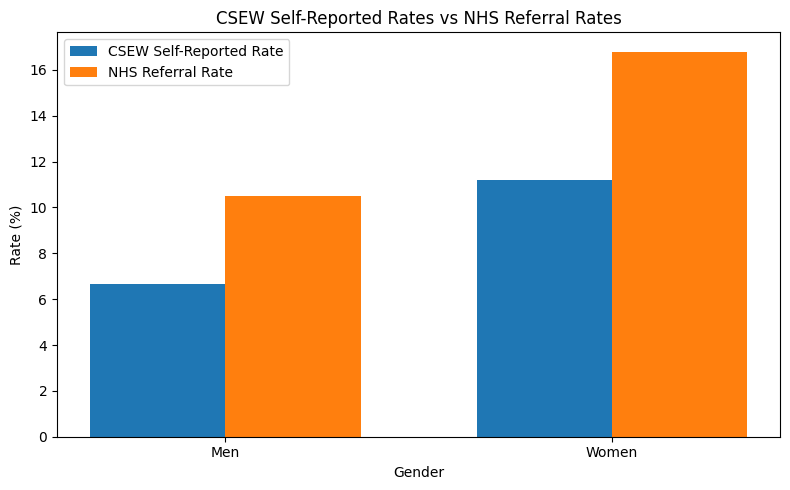

In [16]:
x = np.arange(len(gap_analysis["Gender"]))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width/2,
    gap_analysis["CSEW_Self_Reported_Rate"],
    width,
    label="CSEW Self-Reported Rate"
)

plt.bar(
    x + width/2,
    gap_analysis["NHS_Referral_Rate"],
    width,
    label="NHS Referral Rate"
)

plt.title("CSEW Self-Reported Rates vs NHS Referral Rates")
plt.xlabel("Gender")
plt.ylabel("Rate (%)")
plt.xticks(x, gap_analysis["Gender"])
plt.legend()
plt.tight_layout()

plt.savefig(f"{output_folder}/CSEW_vs_NHS_benchmark_chart.png")
plt.show()


# Chart 2: Gap analysis chart

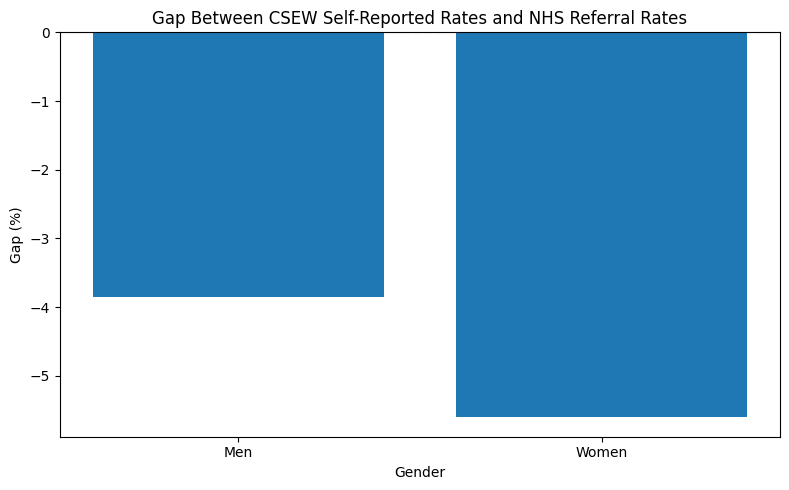

In [17]:
plt.figure(figsize=(8, 5))

plt.bar(
    gap_analysis["Gender"],
    gap_analysis["Gap"]
)

plt.axhline(0, linestyle="--")

plt.title("Gap Between CSEW Self-Reported Rates and NHS Referral Rates")
plt.xlabel("Gender")
plt.ylabel("Gap (%)")
plt.tight_layout()

plt.savefig(f"{output_folder}/CSEW_NHS_gap_chart.png")
plt.show()

# Generate automatic academic interpretation

In [18]:
interpretation_lines = []

for _, row in gap_analysis.iterrows():
    text = (
        f"For {row['Gender']}, the CSEW self-reported rate was "
        f"{row['CSEW_Self_Reported_Rate']:.2f}%, while the NHS referral rate "
        f"was {row['NHS_Referral_Rate']:.2f}%. The resulting gap was "
        f"{row['Gap']:.2f} percentage points, classified as {row['Gap_Level']}."
    )
    interpretation_lines.append(text)

with open(
    f"{output_folder}/gap_analysis_interpretation.txt",
    "w",
    encoding="utf-8"
) as f:
    for line in interpretation_lines:
        f.write(line + "\n")

print("\nInterpretation file created successfully.")


Interpretation file created successfully.


# Create academic summary table

In [19]:

summary_table = gap_analysis.copy()

summary_table["Interpretation"] = summary_table["Gap_Level"].map({
    "Very High Gap": "Very large unmet need; self-reported distress is much higher than NHS referral access.",
    "High Gap": "Clear unmet need; referral access appears lower than reported distress.",
    "Moderate Gap": "Moderate service access gap.",
    "Low Gap": "Small difference between reported distress and referral access.",
    "NHS Rate Higher": "NHS referral rate is higher than self-reported CSEW rate."
})

summary_table.to_csv(
    f"{output_folder}/academic_gap_summary_table.csv",
    index=False
)

print("\nAcademic summary table saved successfully.")


Academic summary table saved successfully.


In [20]:
nhs_benchmark = pd.DataFrame({
    "Gender": ["Men", "Women"],
    "NHS_Referral_Rate": [10.5, 16.8]
})